# Pre-Fit and Post-Fit plots
This notebook plots the pre/post-fit plots using the outputs from running runcards.py and runcombine.py. Firstly, make a `fitDiagnostics.root` file containin the pre/post-fit distributions by activating cmsenv and running 

`combine -M FitDiagnostics combined.root -m 200 --rMin -1 --rMax 2 --saveShapes --saveWithUncertainties`

Note that any other datacard is also fine and should give the same prefit and background only postfit distributions, but make sure to adjust the r-interval (--rMin, --rMax) accordingly.


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import hist.intervals
import numpy as np
import warnings
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import chi2
import mplhep as hep
import os
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerLine2D

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.max_open_warning': 0})
matplotlib.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 70
plt.style.use(hep.style.CMS)
hep.style.use("CMS")

In [2]:
filename = "../WH_test2/cards-SUEP_mS125.000_mPhi3.000_T3.000_modegeneric/fitDiagnostics.root"  # replace with your actual ROOT file path
file = uproot.open(filename)

bins = np.array([30, 40, 50, 80, 200])
centers = np.array( [(bins[i] + bins[i + 1])/2 for i in range(len(bins) - 1)])

FileNotFoundError: file not found

    '../WH_test2/cards-SUEP_mS125.000_mPhi3.000_T3.000_modegeneric/fitDiagnostics.root'

Files may be specified as:
   * str/bytes: relative or absolute filesystem path or URL, without any colons
         other than Windows drive letter or URL schema.
         Examples: "rel/file.root", "C:\abs\file.root", "http://where/what.root"
   * str/bytes: same with an object-within-ROOT path, separated by a colon.
         Example: "rel/file.root:tdirectory/ttree"
   * pathlib.Path: always interpreted as a filesystem path or URL only (no
         object-within-ROOT path), regardless of whether there are any colons.
         Examples: Path("rel:/file.root"), Path("/abs/path:stuff.root")

Functions that accept many files (uproot.iterate, etc.) also allow:
   * glob syntax in str/bytes and pathlib.Path.
         Examples: Path("rel/*.root"), "/abs/*.root:tdirectory/ttree"
   * dict: keys are filesystem paths, values are objects-within-ROOT paths.
         Example

In [4]:
def compute_poisson_interval(values, confidence=0.6827):
    alpha = 1 - confidence
    low = chi2.ppf(alpha / 2., 2 * values) / 2
    high = chi2.ppf(1. - alpha / 2., 2 * (values + 1)) / 2
    #low[np.isnan(low)] = 0
    return low, high

lumis = {
    "2016_apv": 19497.914,
    "2016": 16810.813,
    "2017": 41471.589,
    "2018": 59817.406,
    "all": 19497.914 + 16810.813 + 41471.589 + 59817.406,
}

def lumiLabel(year):
    if year in ["2017", "2018"]:
        return round(lumis[year] / 1000, 1)
    elif year == "2016":
        return round((lumis[year] + lumis[year + "_apv"]) / 1000, 1)
    elif year == 'all':
        return round(lumis[year] / 1000, 1)

In [3]:
def read_post_fit_file(postFitFile, bins, years, regions):
   
    payload, payload_err = {}, {}
    for region in regions:
        
        payload[region], payload_err[region] = {}, {}

        for year in years:

            payload[region][year], payload_err[region][year] = {}, {}
        
            for fit in ['fit_b', 'prefit']:
                   
                payload[region][year][fit], payload_err[region][year][fit] = {}, {}
                payload[region][year]['data'], payload_err[region][year]['data'] = {}, {}

                for bin in bins:

                    name = 'shapes_{}/{}{};1'.format(fit, region+bin, year)
                    
                    payload[region][year][fit][bin] = postFitFile[name][region+'expected;1'].values()[0]
                    payload_err[region][year][fit][bin] = np.sqrt(postFitFile[name]['total_covar;1'].to_numpy()[0][0][0])

                    payload[region][year]['data'][bin] = postFitFile[name]['data;1'].values()[1][0]
                    payload_err[region][year]['data'][bin] = np.array(compute_poisson_interval(payload[region][year]['data'][bin]))

    return payload, payload_err

def create_plot_objects(_rpayload, _rpayload_err):

    hist_defs = {
        'A': {'channels': ['crA'], 'bins': [20, 30]},
        'B': {'channels': ['crB'], 'bins': [30, 120]},
        'C': {'channels': ['crC'], 'bins': [20, 30]},
        'D': {'channels': ['crD0', 'crD1', 'crD2', 'crD3', 'crD4'], 'bins': [30, 40, 50, 60, 80, 120]},
        'E': {'channels': ['crE'], 'bins': [20, 30]},
        'SR': {'channels': ['sr0', 'sr1', 'sr2', 'sr3', 'sr4'], 'bins': [30, 40, 50, 60, 80, 120]},
    }

    for hist_name, hist_def in hist_defs.items():

        # pre fit values (only relevant for ABCD prediction in SR, other regions are identical to data observed)
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['2018']['prefit'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['2018']['prefit'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['prefit'] = h

        # post fit values for each region
        h = hist.new.Variable(hist_def['bins'], name=hist_name).Weight()
        values = np.array([_rpayload['2018']['fit_b'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['2018']['fit_b'][ch] for ch in hist_def['channels']])
        h[:] = np.stack([values, errors], axis=-1)
        hist_defs[hist_name]['fit_b'] = h

        # observed data for each region
        hist_defs[hist_name]['centers'] = h.axes[0].centers
        values = np.array([_rpayload['2018']['data'][ch] for ch in hist_def['channels']])
        errors = np.array([_rpayload_err['2018']['data'][ch] for ch in hist_def['channels']])
        errors[np.isnan(errors)] = 0
        hist_defs[hist_name]['data'] = values
        hist_defs[hist_name]['data_err'] = np.array([values-errors[:,0], errors[:,1] - values])

        # get values of ratio of post-fit to observed data
        r_post_data = np.divide(hist_defs[hist_name]['fit_b'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_post_data_err = np.sqrt( ((hist_defs[hist_name]['fit_b'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['fit_b'].variances()))
        hist_defs[hist_name]['r_post_data'] = r_post_data
        hist_defs[hist_name]['r_post_data_err'] = r_post_data_err

        # get values of ratio of pre-fit to observed data 
        r_prefit_data = np.divide(hist_defs[hist_name]['prefit'].values(), hist_defs[hist_name]['data'], where=hist_defs[hist_name]['data']!=0, out=np.ones_like(hist_defs[hist_name]['data']))
        r_prefit_data_err = np.sqrt( ((hist_defs[hist_name]['prefit'].values()**2)*(hist_defs[hist_name]['data']**-4))*(hist_defs[hist_name]['data']) + (hist_defs[hist_name]['data']**-2)*(hist_defs[hist_name]['prefit'].values()))
        hist_defs[hist_name]['r_prefit_data'] = r_prefit_data
        hist_defs[hist_name]['r_prefit_data_err'] = r_prefit_data_err
    
    return hist_defs

def make_postfit(plot_objs, region='', pretty_region=''):

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 8), sharey=False, sharex=True, 
                            gridspec_kw={'height_ratios': [3,1], 'hspace':0.1, 'wspace':0}) #Plot 3 subplots
    fig.subplots_adjust(wspace=0) 
    (ax1, ax2, ax3) = axes[0]
    (ax1r, ax2r, ax3r) = axes[1]

    ax1.errorbar(plot_objs['A']['centers'], plot_objs['A']['data'], plot_objs['A']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax1.errorbar(plot_objs['B']['centers'], plot_objs['B']['data'], plot_objs['B']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['C']['centers'], plot_objs['C']['data'], plot_objs['C']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax2.errorbar(plot_objs['D']['centers'], plot_objs['D']['data'], plot_objs['D']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['E']['centers'], plot_objs['E']['data'], plot_objs['E']['data_err'], capsize=3, linestyle='', fmt='o', color='black')
    ax3.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['data'], plot_objs['SR']['data_err'], capsize=3, linestyle='', fmt='o', color='black')

    hep.histplot(plot_objs['SR']['prefit'], ax=ax3, color='slategray', yerr=False, linewidth=3)

    for hist_name, hist_def in plot_objs.items():
        if hist_name != 'SR': continue
        _bins = hist_def['bins']
        _vals = hist_def['prefit'].values()
        _vars = np.sqrt(hist_def['prefit'].variances())
        ax = ax1 if hist_name in ['A', 'B'] else ax2 if hist_name in ['C', 'D'] else ax3
        for i in range(len(_bins)-1):
            ax.fill_between([_bins[i], _bins[i+1]], 
                            _vals[i] - _vars[i], 
                            _vals[i] + _vars[i], 
                            color='slategray', alpha=0.3)

    hep.histplot(plot_objs['A']['fit_b'], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['B']['fit_b'], ax=ax1, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['C']['fit_b'], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['D']['fit_b'], ax=ax2, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['E']['fit_b'], ax=ax3, color='purple', yerr=False, linewidth=3)
    hep.histplot(plot_objs['SR']['fit_b'], ax=ax3, color='purple', yerr=False, linewidth=3)

    for hist_name, hist_def in plot_objs.items():
        _bins = hist_def['bins']
        _vals = hist_def['fit_b'].values()
        _vars = np.sqrt(hist_def['fit_b'].variances())
        ax = ax1 if hist_name in ['A', 'B'] else ax2 if hist_name in ['C', 'D'] else ax3
        for i in range(len(_bins)-1):
            ax.fill_between([_bins[i], _bins[i+1]], 
                            _vals[i] - _vars[i], 
                            _vals[i] + _vars[i], 
                            color='purple', alpha=0.3)

    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_prefit_data'], plot_objs['SR']['r_prefit_data_err'], capsize=3, linestyle='', fmt='o', color='slategray')

    ax1r.errorbar(plot_objs['A']['centers'], plot_objs['A']['r_post_data'], plot_objs['A']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax1r.errorbar(plot_objs['B']['centers'], plot_objs['B']['r_post_data'], plot_objs['B']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['C']['centers'], plot_objs['C']['r_post_data'], plot_objs['C']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax2r.errorbar(plot_objs['D']['centers'], plot_objs['D']['r_post_data'], plot_objs['D']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['E']['centers'], plot_objs['E']['r_post_data'], plot_objs['E']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')
    ax3r.errorbar(plot_objs['SR']['centers'], plot_objs['SR']['r_post_data'], plot_objs['SR']['r_post_data_err'], capsize=3, linestyle='', fmt='o', color='purple')

    # pretty up
    line, = plt.plot(range(10), color = 'purple')
    patch = mpatches.Patch(facecolor='purple', alpha=0.3, linewidth=0)
    line2, = plt.plot(range(10), color = 'slategray')
    patch2 = mpatches.Patch(facecolor='slategray', alpha=0.3, linewidth=0)
    line3 = plt.errorbar(1000,0, yerr=10, label='Observed', linestyle='',c='black',capsize=2.0,fmt ='.')
    ax3.legend([line3, (patch, line), (patch2, line2)], 
            ["Observed", "Post-Fit\n(b. only)", "Pre-Fit"], 
            handler_map = {line : HandlerLine2D(marker_pad = 0)}, 
            loc=(0.65, 0.40), fontsize=18)
    if pretty_region:
        ax3.text(0.68, 0.77, pretty_region,
            fontsize=20, transform=ax3.transAxes)
    cms = ax1.text(
        0.0,1.01, u"CMS",
        fontsize=24, fontweight='bold',
        transform=ax1.transAxes, 
        horizontalalignment='left'
    )
    lumi = ax3.text(
        1.0,1.01, r"%.0f fb$^{-1}$ ($13$ TeV)" % round(lumiLabel('2018')),
        transform=ax3.transAxes, 
        horizontalalignment='right'
    )
    ax1.set_ylabel('Events')
    if region in ['GJHS', 'WJHS']:
        ax1.text(0.95, 0.95, '0.3 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.4', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax2.text(0.95, 0.95, '0.4 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.5', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax3.text(0.95, 0.95, '0.5 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 1.0', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    elif region in ['GJLS', 'WJLS']:
        ax1.text(0.95, 0.95, '0.05 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.15', transform=ax1.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax2.text(0.95, 0.95, '0.15 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.25', transform=ax2.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
        ax3.text(0.95, 0.95, '0.25 < $S^{\mathrm{SUEP}}_{\mathrm{boosted}}$ < 0.3', transform=ax3.transAxes, fontsize=20, verticalalignment='top', horizontalalignment='right')
    ax1.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax2.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax3.axvline(30, color='gray', linewidth=3, linestyle='-')
    ax1r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax2r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax3r.axhline(1, color='gray', linewidth=3, linestyle='--', zorder=0)
    ax1r.set_ylim(0.1, 1.8)
    ax2r.set_ylim(0.1, 1.8)
    ax3r.set_ylim(0.1, 1.8)
    ax1.set_xlim(10, 125)
    ax2.set_xlim(10, 125)
    ax3.set_xlim(10, 125)
    ax1.set_ylim(5e-1, 1e6)
    ax2.set_ylim(5e-1, 1e6)
    ax3.set_ylim(5e-1, 1e6)
    ax1.set_xlabel('')
    ax2.set_xlabel('')
    ax3.set_xlabel('')
    ax1r.set_ylabel("Pred./Obs.")
    ax3r.set_xlabel('$n^{\mathrm{SUEP}}_{\mathrm{constituents}}$')
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    ax3.set_yscale("log")
    for i in range(2):
        for j in range(3):
            if j > 0:  # Check if the column is not the first column
                axes[i, j].set_yticklabels([])  # Remove y-axis labels
    fig.tight_layout()
    fig.show()

    return fig, (ax1, ax2, ax3), (ax1r, ax2r, ax3r)

In [4]:
years = ['2018']
bins = [
    'sr0','sr1','sr2','sr3','sr4',
    'crD0','crD1','crD2','crD3','crD4',
    'crA', 'crB', 'crC', 'crD', 'crE',
]
regions = ['WJHS', 'WJLS', 'GJHS', 'GJLS']

payload, payload_err = read_post_fit_file(file, bins, years, regions)
payload

NameError: name 'file' is not defined

In [5]:
payload_err

NameError: name 'payload_err' is not defined

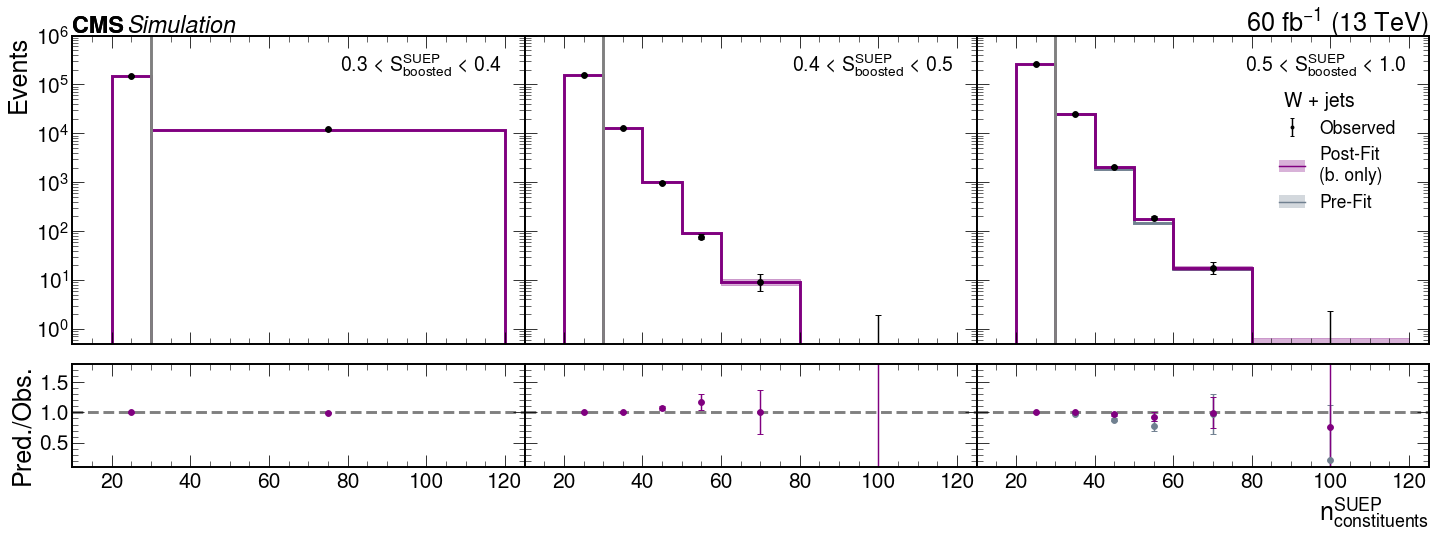

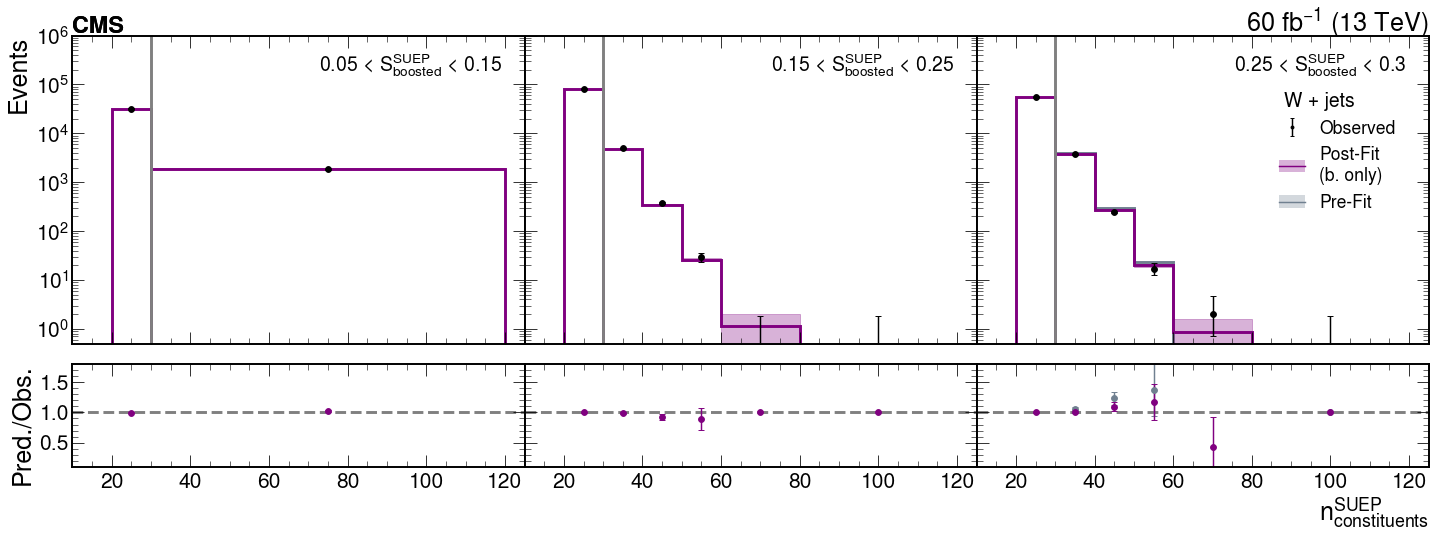

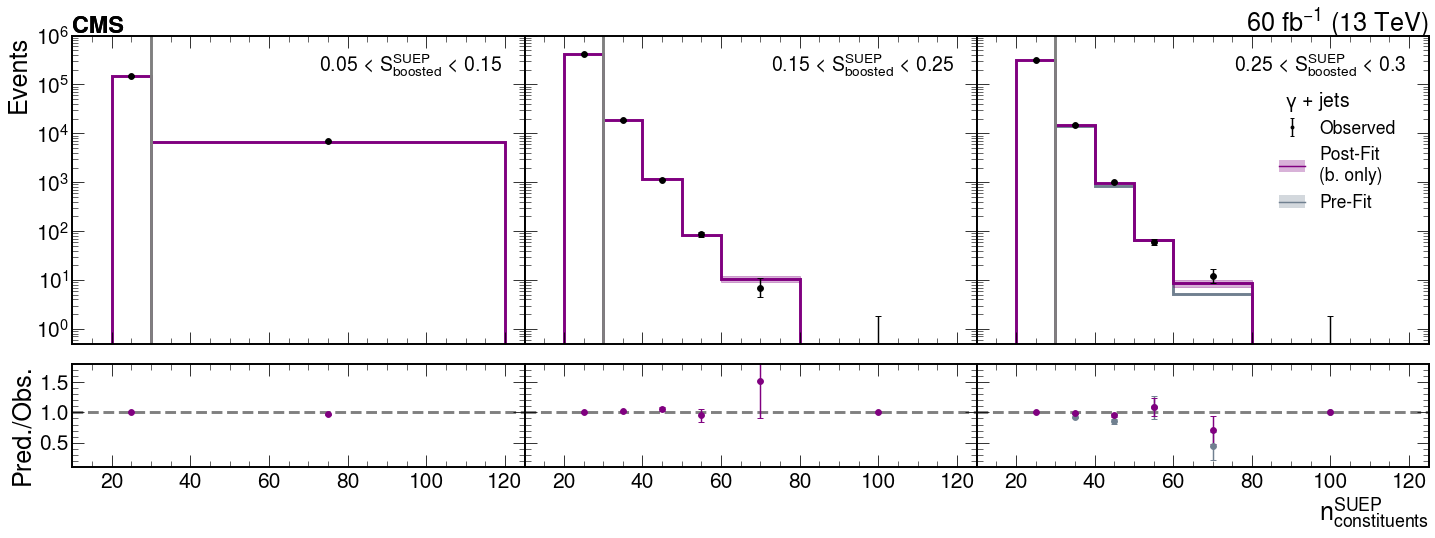

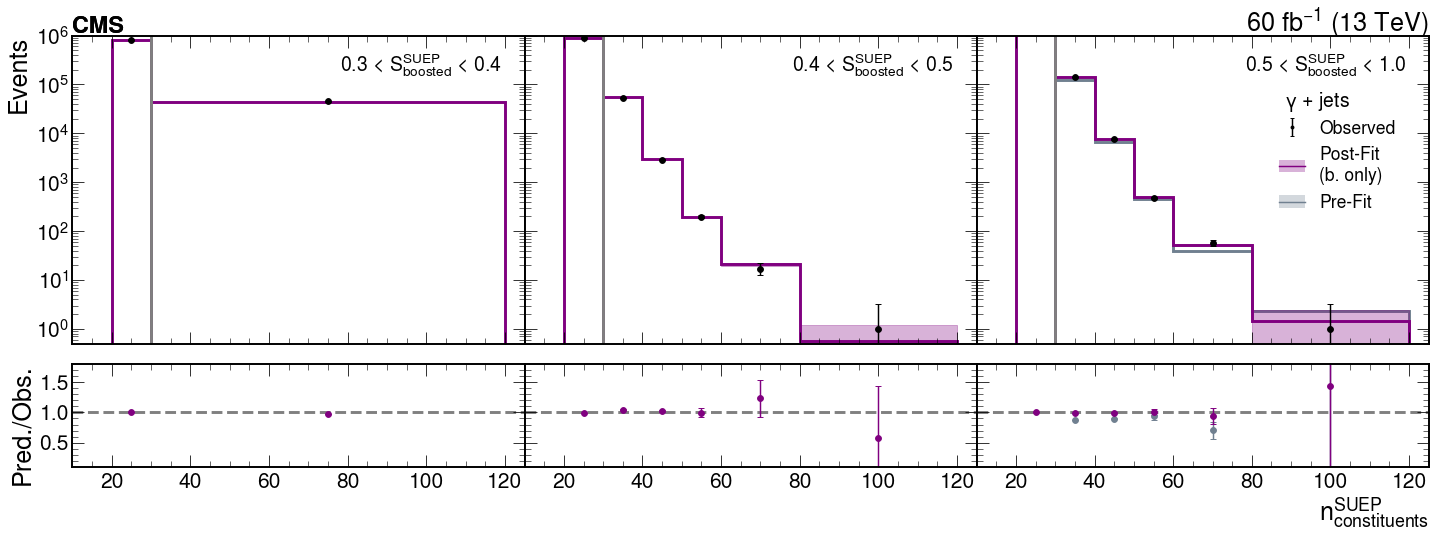

In [142]:
WJHS_plot_objs = create_plot_objects(payload['WJHS'], payload_err['WJHS'])
WJHSfig, WJHSaxs, WJHSaxrs = make_postfit(WJHS_plot_objs, region='WJHS', pretty_region='W + jets')
cms = WJHSaxs[0].text(
    0.0, 1.01, u"CMS ",
    fontsize=24, fontweight='bold',
    transform=WJHSaxs[0].transAxes, 
    horizontalalignment='left'
)
simulation = WJHSaxs[0].text(
    0.12, 1.01, u"Simulation",
    fontsize=24, fontstyle='italic',
    transform=WJHSaxs[0].transAxes, 
    horizontalalignment='left'
)
WJLS_plot_objs = create_plot_objects(payload['WJLS'], payload_err['WJLS'])
WJLSfig, WJLSaxs, WJLSaxrs = make_postfit(WJLS_plot_objs, region='WJLS', pretty_region='W + jets')
cms = WJLSaxs[0].text(
    0.0, 1.01, u"CMS ",
    fontsize=24, fontweight='bold',
    transform=WJLSaxs[0].transAxes, 
    horizontalalignment='left'
)
GJLS_plot_objs = create_plot_objects(payload['GJLS'], payload_err['GJLS'])
GJLSfig, GJLSaxs, GJLSaxrs = make_postfit(GJLS_plot_objs, region='GJLS', pretty_region='$\gamma$ + jets')
cms = GJLSaxs[0].text(
    0.0, 1.01, u"CMS ",
    fontsize=24, fontweight='bold',
    transform=GJLSaxs[0].transAxes, 
    horizontalalignment='left'
)
GJHS_plot_objs = create_plot_objects(payload['GJHS'], payload_err['GJHS'])
GJHSfig, GJHSaxs, GJHSaxrs = make_postfit(GJHS_plot_objs, region='GJHS', pretty_region='$\gamma$ + jets')
cms = GJHSaxs[0].text(
    0.0, 1.01, u"CMS ",
    fontsize=24, fontweight='bold',
    transform=GJHSaxs[0].transAxes, 
    horizontalalignment='left'
)

In [27]:
labels = ['Bin1Sig','Bin2Sig','Bin3Sig','Bin4Sig',
            'Bin0crF','Bin1crF','Bin2crF','Bin3crF','Bin4crF',
            'catcrA', 'catcrB', 'catcrC', 'catcrD', 'catcrE',
            'catcrG', 'catcrH']
labels = [  'Bin0crF','Bin1crF','Bin2crF','Bin3crF','Bin4crF']

header = ' & '
for y in payload.keys(): header+= ' & ' + str(y)
print(header + r'\\')
for iBin in range(len(labels)):
    line1, line2, line3 = '', '', ''
    line1 += ' & Exp.'
    line2 += labels[iBin] 
    line2 += ' & Prefit'
    #line3 += ' & Obs.'
    
    for year in payload.keys():
        line1 += ' & '
        v, e = payload[year]['fit_b'][labels[iBin]], payload_err[year]['fit_b'][labels[iBin]]
        v, e = sf(v, e)
        line1 += '${} \pm {}$'.format(v, e)

        # v, e = payload[year]['prefit'][labels[iBin]], payload_err[year]['prefit'][labels[iBin]]
        # v, e = sf(v, e)
        # line3 += ' & ${} \pm {}$'.format(v, e)

        v, e = payload[year]['data'][labels[iBin]][0], payload_err[year]['data'][labels[iBin]]
        e_d, e_u = e
        if np.isnan(e_d[0]): e_d[0] = 0
        line2 += ' & $' + str(v) + '^{' + str(round(e_u[0] - v)) + '}_{-' + str(round(v - e_d[0])) + '}$'
    
    line1 += r'\\'
    line2 += r'\\'
    line3 += r'\\'
    
    print('\hline')
    #print(line3)
    print(line1)
    print(line2)

 &  & 2018\\


KeyError: 'Bin0crF'